In [ ]:
!pip install git+https://github.com/maods2/mdmp.git

In [1]:
%matplotlib inline

import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from mdmp import (
    DAG_LABELS,
    MDM,
    aggregate_by_level,
    compute_gs,
    compute_is,
    compute_vts,
    detect_anomalies,
    fit_individual_structures,
    list_datasets,
    load_dataset,
    load_retail,
    plot_anomalies,
    plot_arcs,
    plot_dag,
    plot_dendrogram,
    plot_idag,
    plot_marginal,
    plot_mdp,
    plot_projection,
    plot_stream,
)

D:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
list_datasets()
data = load_dataset("covid_regional_timeseries")
data.head()

,Southeast,Midwest,Northeast,North,South
0,0.0002,0.0000,0.0000,0.0000,0.0000
1,0.0019,0.0001,0.0003,0.0000,0.0000
2,0.0169,0.0031,0.0031,0.0002,0.0021
3,0.0949,0.0156,0.0282,0.0065,0.0221
4,0.1381,0.0247,0.0497,0.0195,0.0391


In [3]:
sales, hierarchy = load_retail()
c3 = aggregate_by_level(sales, hierarchy, "type")
model = MDM(c3, method="hc", verbose=True, n_jobs=1)

Learning structure using method: hc



  0%|          | 0/1000000 [00:00<?, ?it/s]


  0%|          | 1/1000000 [00:03<1102:07:08,  3.97s/it]


  0%|          | 2/1000000 [00:04<578:05:27,  2.08s/it] 


  0%|          | 3/1000000 [00:05<366:05:40,  1.32s/it]

...


Filtering nodes: 7it [00:00, 145.60it/s]

Computing smoothed estimates...



Smoothing nodes: 0it [00:00, ?it/s]


Smoothing nodes: 7it [00:00, 93.12it/s]


MDM processing completed in 12.43 seconds


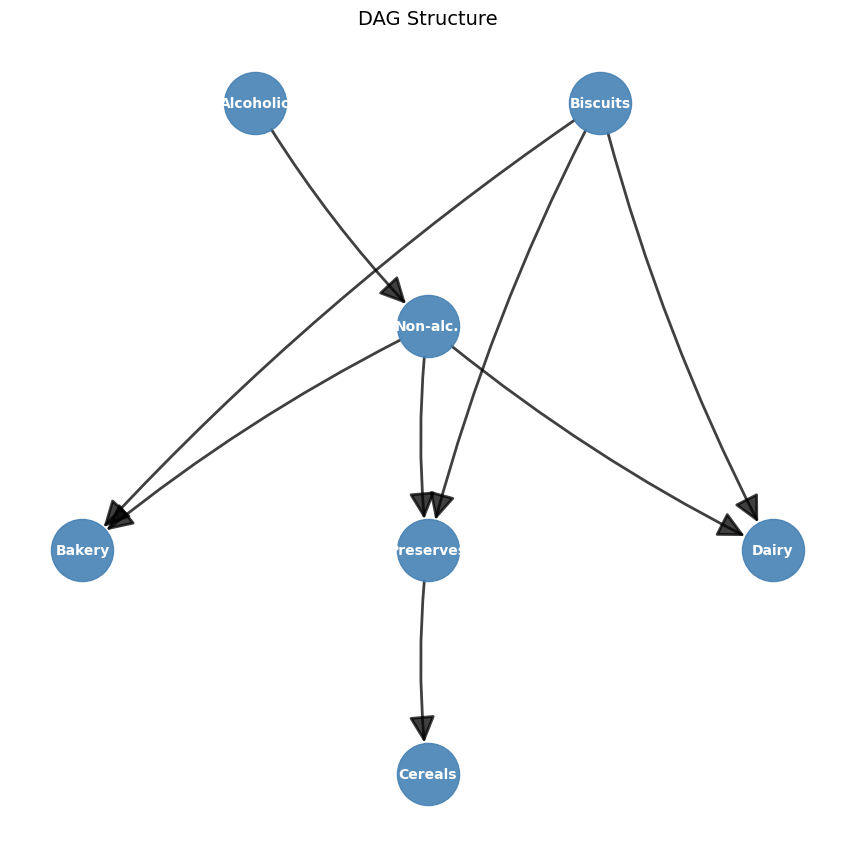

In [4]:
node_labels = [DAG_LABELS.get(n, n) for n in model.node_names]
try:
    plot_dag(model, plot_type="graph", node_labels=node_labels)
except (OSError, RuntimeError, ImportError):
    plot_dag(model, plot_type="graph", node_labels=node_labels, style="networkx")

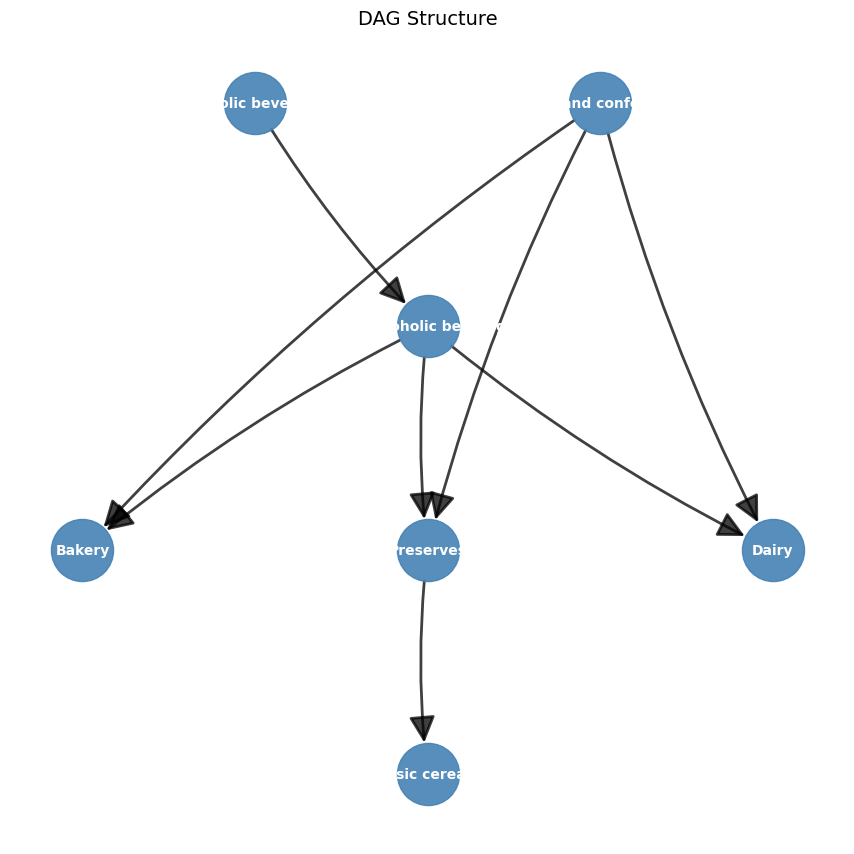

In [5]:
try:
    plot_dag(model, plot_type="graph")
except (OSError, RuntimeError, ImportError):
    plot_dag(model, plot_type="graph", style="networkx")

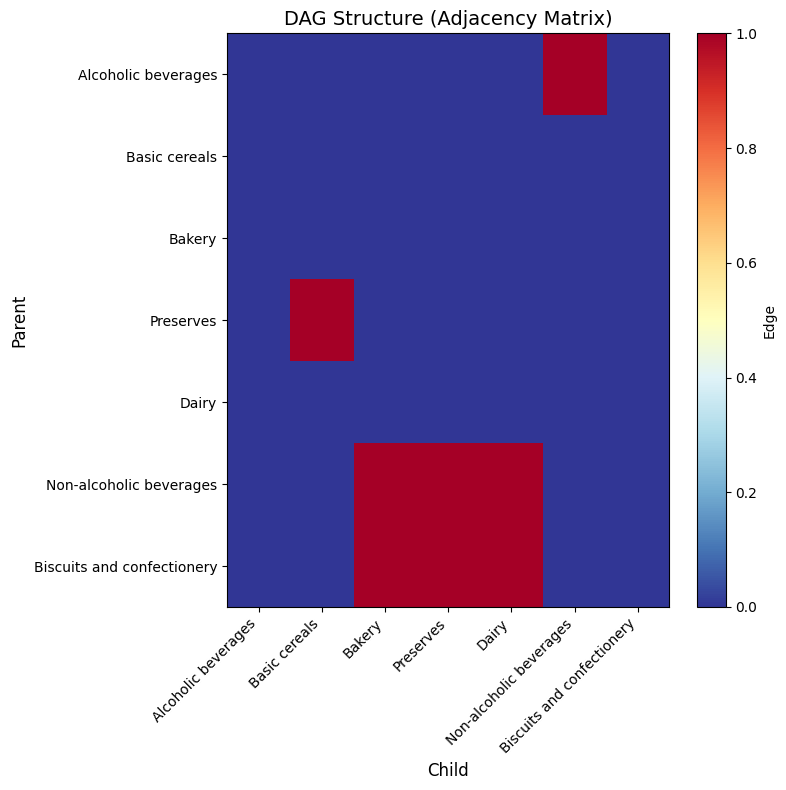

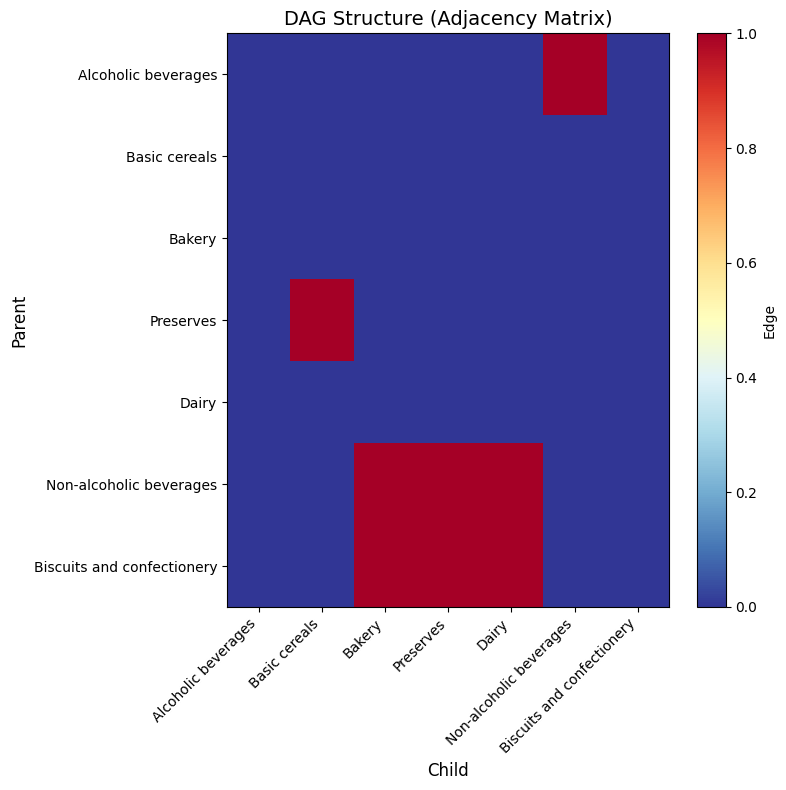

In [6]:
plot_dag(model, plot_type="heatmap")

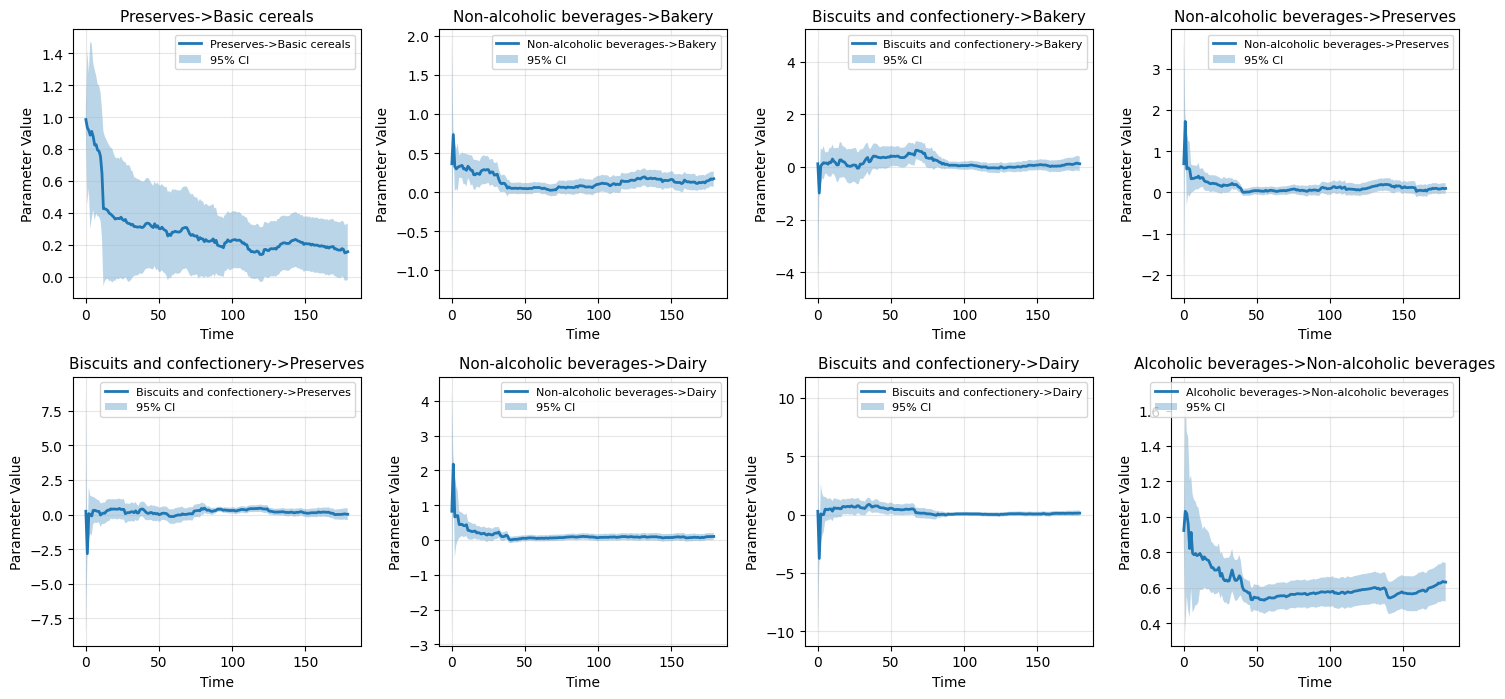

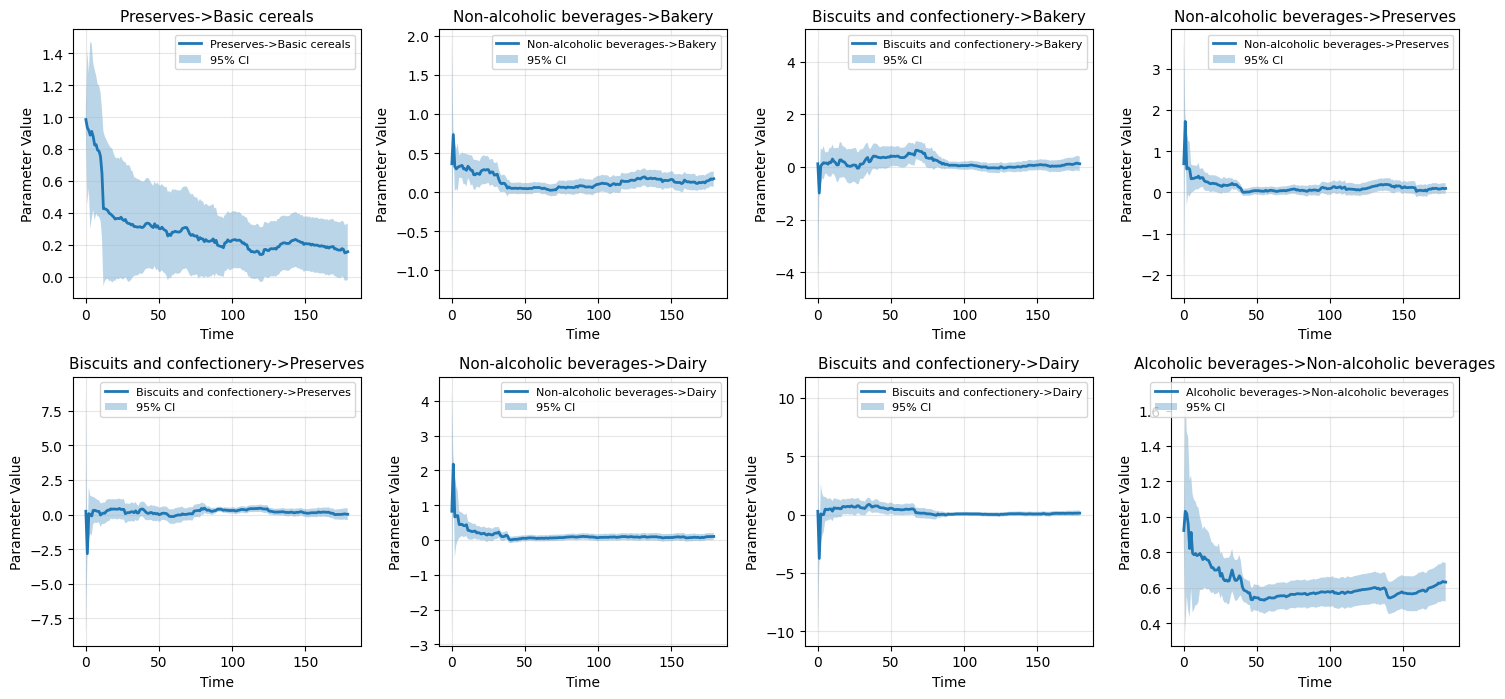

In [7]:
plot_arcs(model, plot_type="connections", distribution="filt", ci_level=0.95)

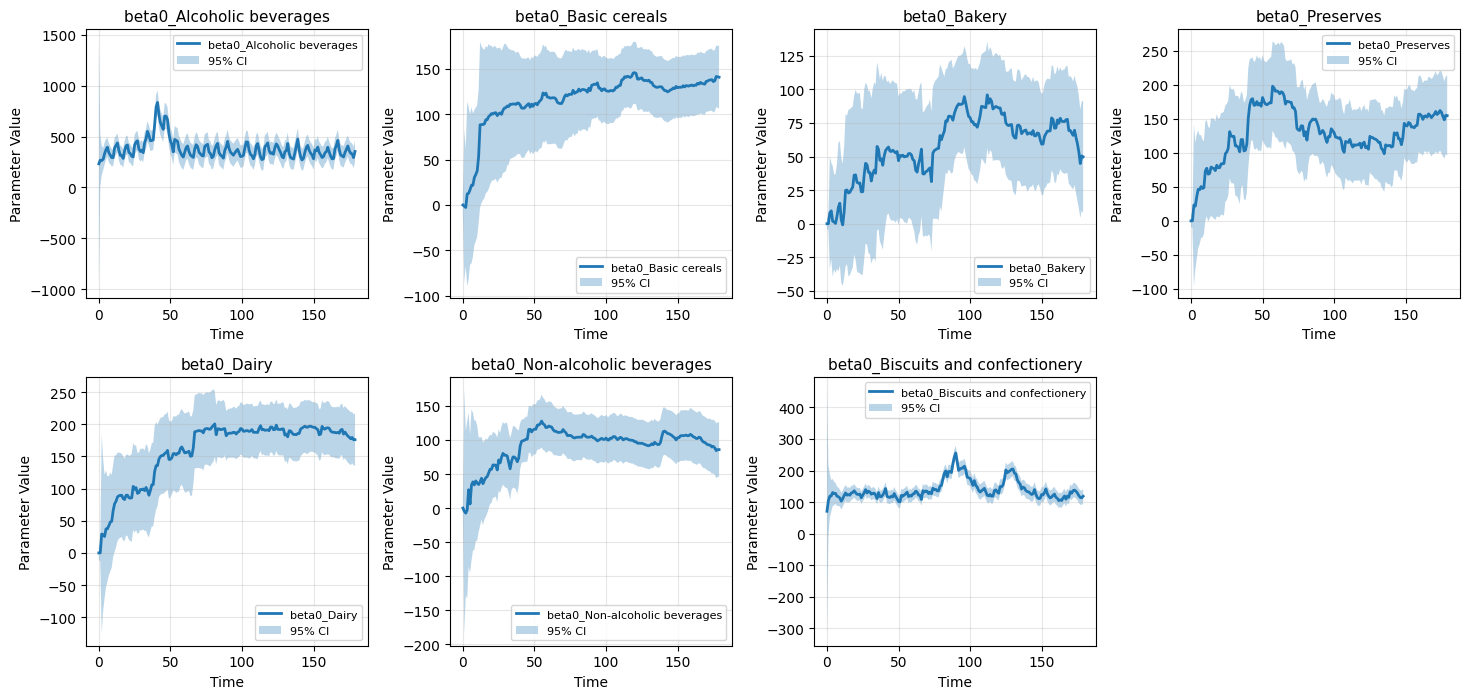

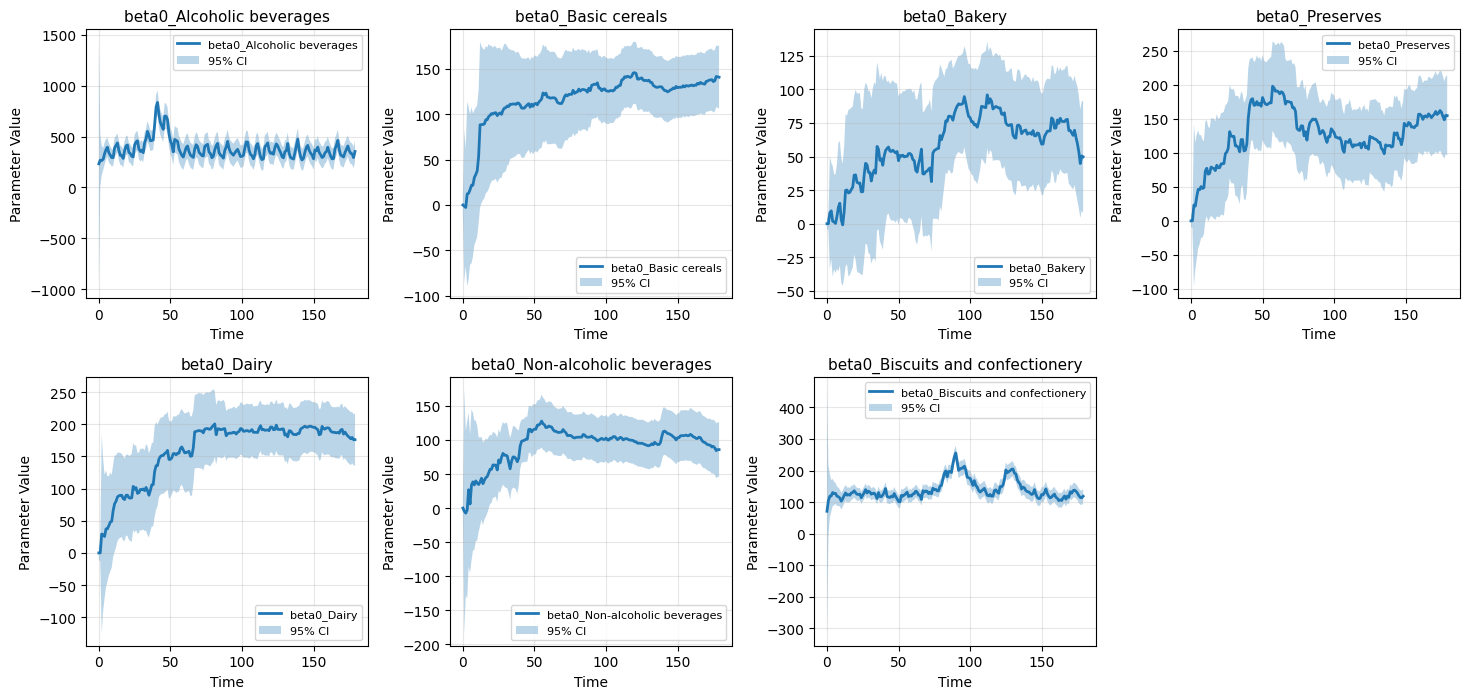

In [8]:
plot_arcs(model, plot_type="intercepts", distribution="filt")

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.PillowWriter'>


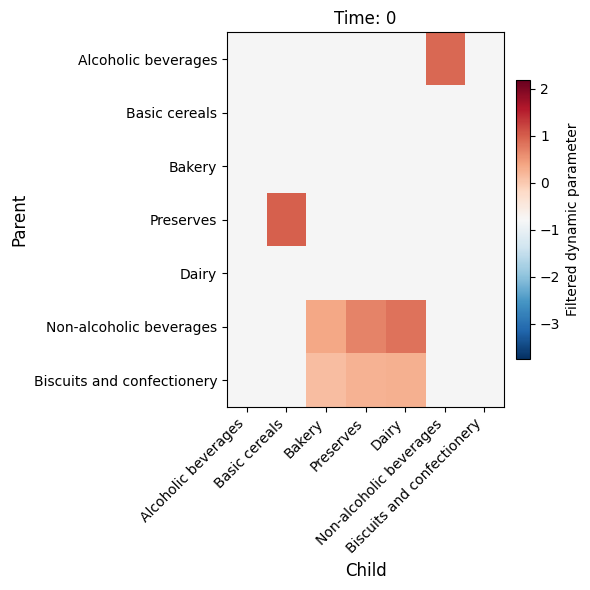

In [9]:
gif_path = Path(tempfile.gettempdir()) / "mdm_dynamic_readme_demo.gif"
plot_idag(
    mdm_object=model,
    output_gif=str(gif_path),
    fps=10,
    width=6,
    height=6,
    dpi=100,
)

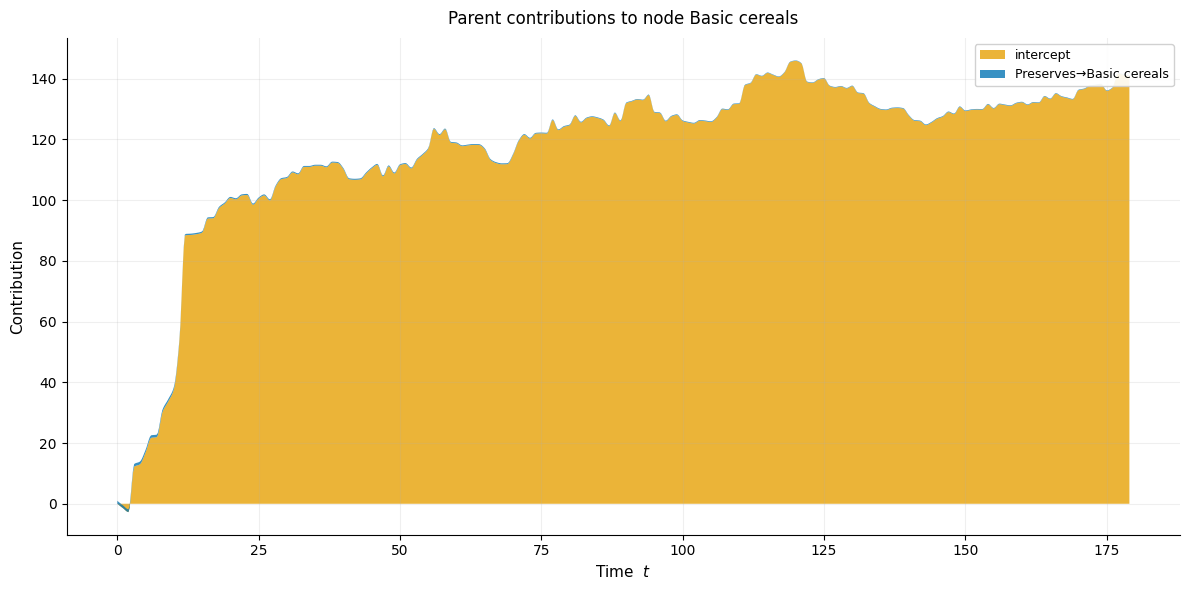

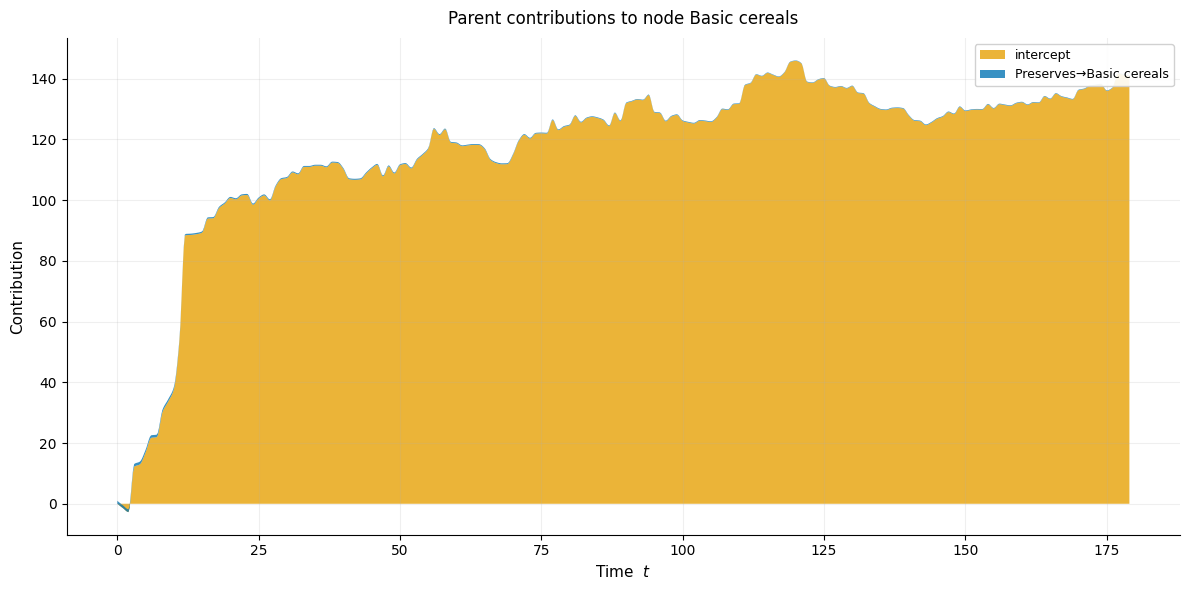

In [10]:
child_node = next(
    (i for i in range(model.adj_mat.shape[0]) if np.sum(model.adj_mat[:, i]) > 0),
    0,
)
plot_stream(mdm_object=model, child_node=child_node, distribution="filt")

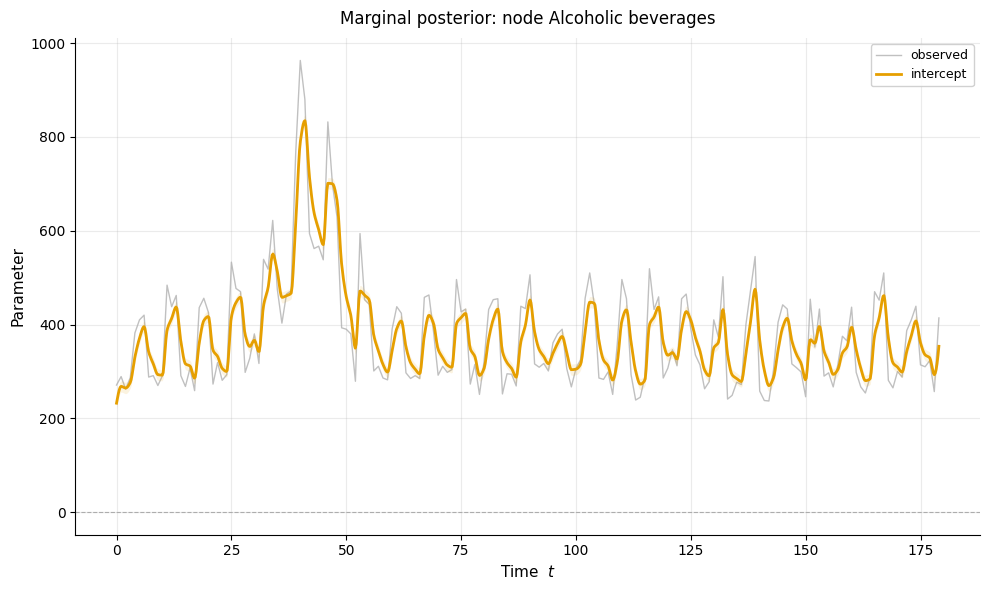

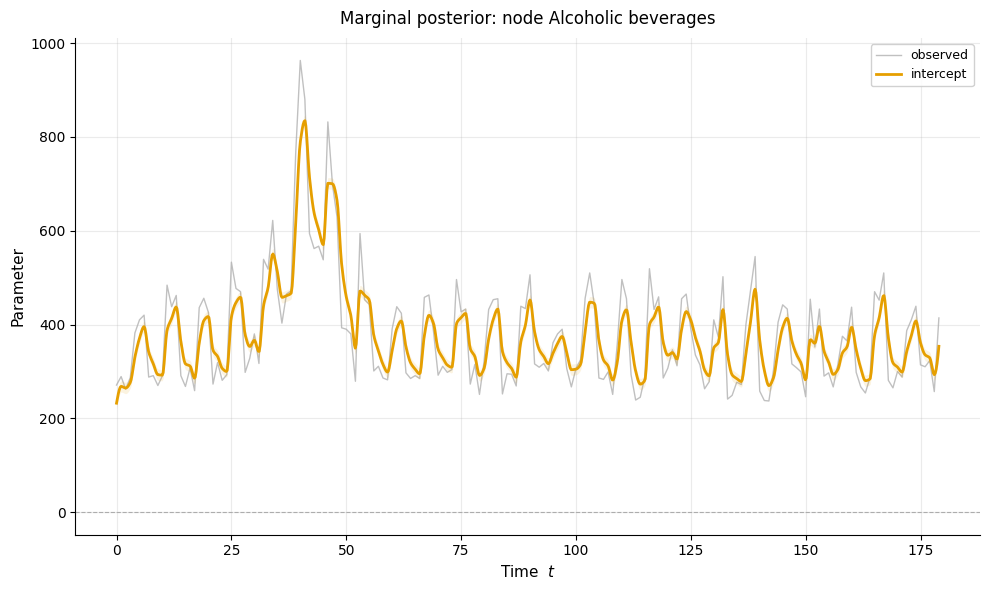

In [11]:
plot_marginal(mdm_object=model, distribution="filt", target_node=0, scale_series=False)

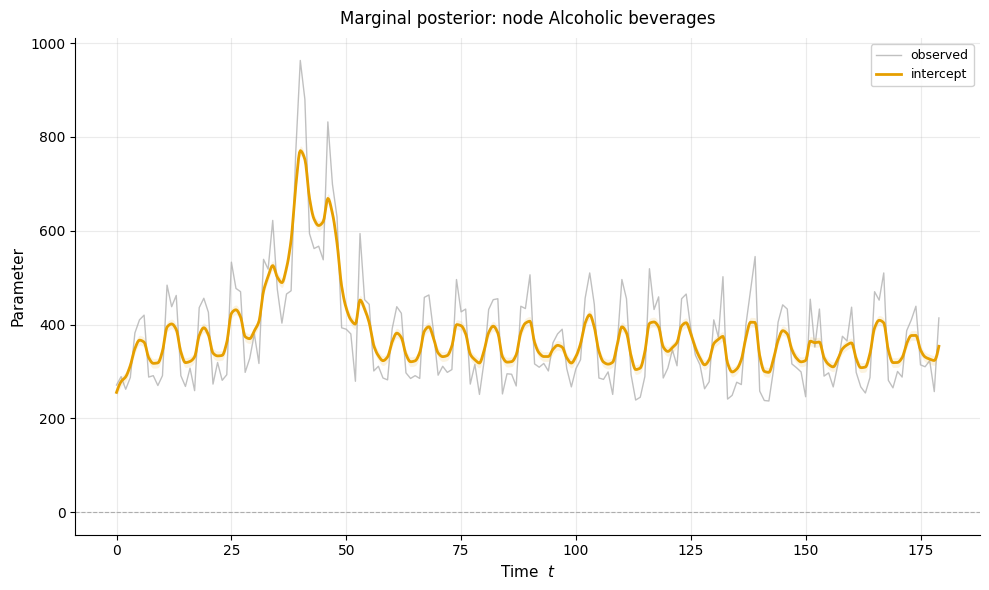

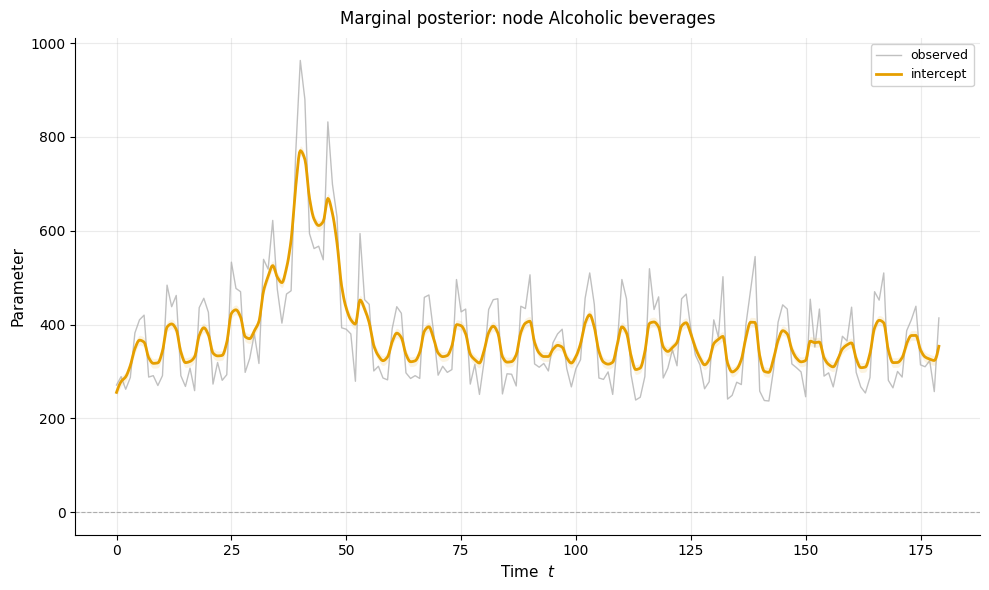

In [12]:
plot_marginal(mdm_object=model, distribution="smoo", target_node=0, scale_series=False)

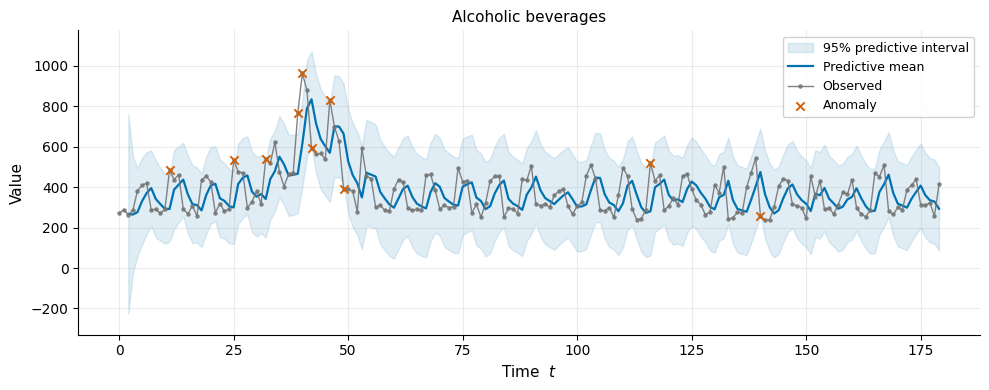

In [13]:
result = detect_anomalies(model, ci_level=0.95)
df = detect_anomalies(model, series=model.node_names[0], output="dataframe")
fig = plot_anomalies(model, series=0, ci_level=0.95)

D:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
D:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
D:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:779: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
D:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
D:\dev\phd\sandbox\m

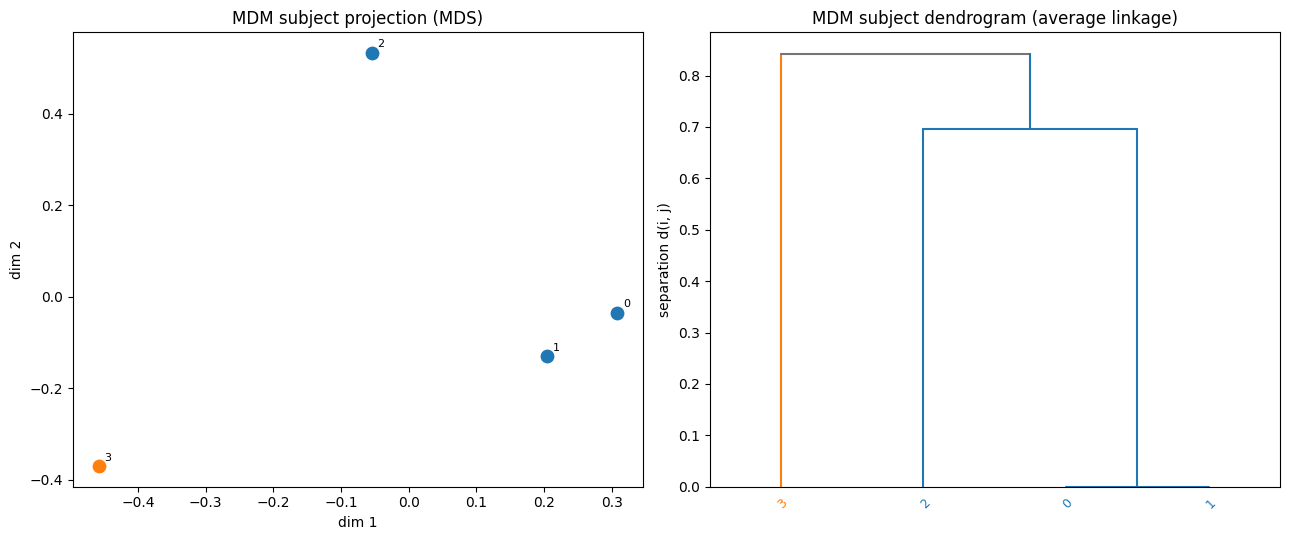

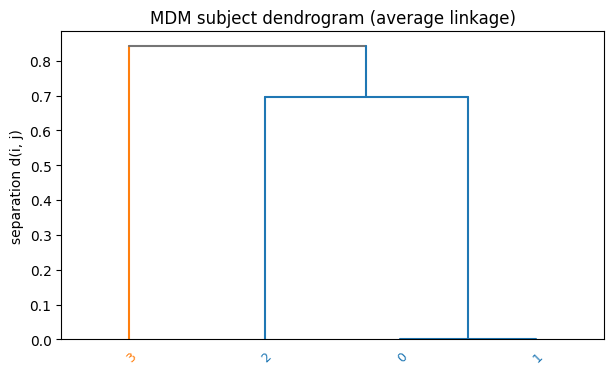

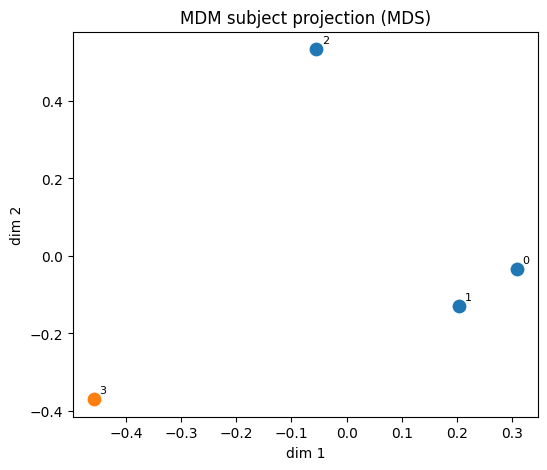

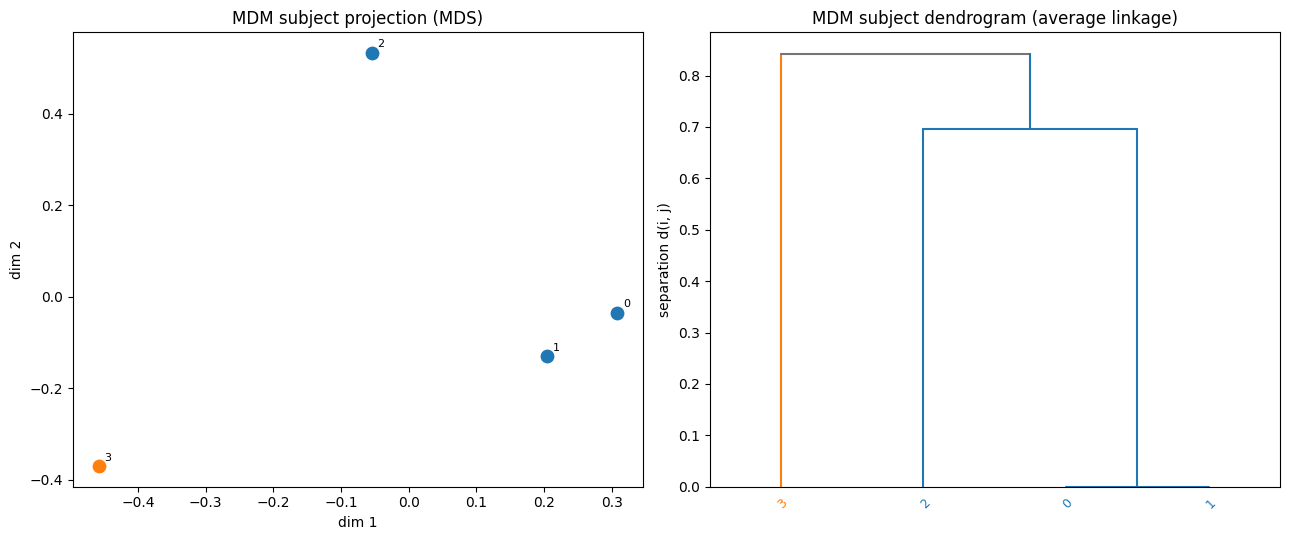

In [14]:
rng = np.random.default_rng(0)
subjects = []
for _ in range(4):
    e = rng.normal(size=(50, 3))
    x = np.zeros_like(e)
    x[:, 0] = e[:, 0]
    x[:, 1] = 0.6 * x[:, 0] + e[:, 1]
    x[:, 2] = e[:, 2]
    subjects.append(x)

individuals = fit_individual_structures(subjects, method="hc", verbose=False)
dist = compute_gs(individuals, verbose=False)

plot_dendrogram(dist, n_clusters=2)
plot_projection(dist, technique="mds", n_clusters=2)
plot_mdp(dist, technique="mds", n_clusters=2)

In [15]:
data = load_dataset("mdmr_test_data")
tabu_model = MDM(data, method="tabu", tabu_length=50, max_iter=1000, verbose=True)

Learning structure using method: tabu



  0%|          | 0/1000 [00:00<?, ?it/s]


  0%|          | 1/1000 [00:02<37:27,  2.25s/it]


  0%|          | 2/1000 [00:02<17:15,  1.04s/it]


  0%|          | 3/1000 [00:02<10:41,  1.55it/s]

...


Filtering nodes: 4it [00:00, 133.14it/s]

Computing smoothed estimates...



Smoothing nodes: 0it [00:00, ?it/s]


Smoothing nodes: 4it [00:00, 112.08it/s]


MDM processing completed in 4.83 seconds


In [16]:
vts_data = np.stack(subjects)
result = compute_vts(vts_data, method="mean")
result = compute_vts(vts_data, method="median")
result = compute_vts(subjects, method="concatenation")
vts_model = MDM(result.vts_data, method="hc")

Learning structure using method: hc



  0%|          | 0/1000000 [00:00<?, ?it/s]


  0%|          | 1/1000000 [00:01<389:49:20,  1.40s/it]


  0%|          | 1/1000000 [00:01<428:04:12,  1.54s/it]

Selecting discount factors...


...


Filtering nodes: 3it [00:00, 150.74it/s]

Computing smoothed estimates...



Smoothing nodes: 0it [00:00, ?it/s]


Smoothing nodes: 3it [00:00, 107.94it/s]


MDM processing completed in 2.71 seconds


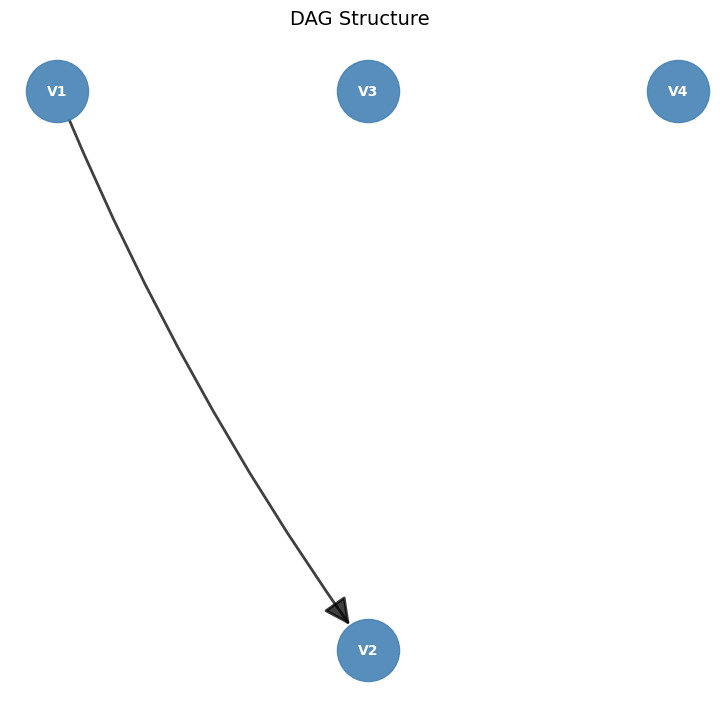

In [17]:
list_of_adj_mats = [
    np.array([[0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 0], [0, 0, 0, 0]], dtype=int),
    np.array([[0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 0], [0, 0, 0, 0]], dtype=int),
    np.array([[0, 0, 1, 0], [0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 0, 0]], dtype=int),
    np.array([[0, 1, 1, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]], dtype=int),
    np.array([[0, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [0, 0, 0, 0]], dtype=int),
    np.array([[0, 1, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]], dtype=int),
]
result = compute_is(list_of_adj_mats, tau=0.5, mc_n_samples=0)
try:
    fig = plot_dag(result)
except (OSError, RuntimeError, ImportError):
    fig = plot_dag(result, style="networkx")

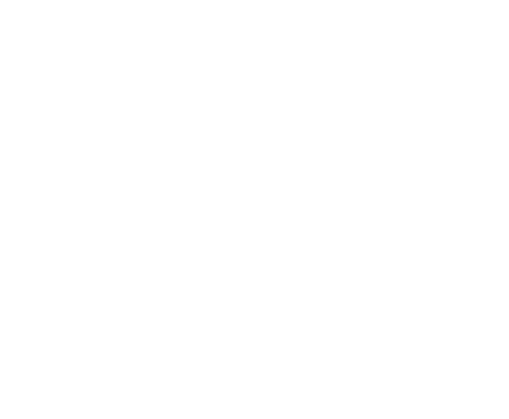

In [18]:
list_of_mdm_models = individuals
result = compute_is(list_of_mdm_models, tau=0.5, mc_n_samples=0)
fig2 = plot_arcs(result, plot_type="connections")

D:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


D:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
D:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:779: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


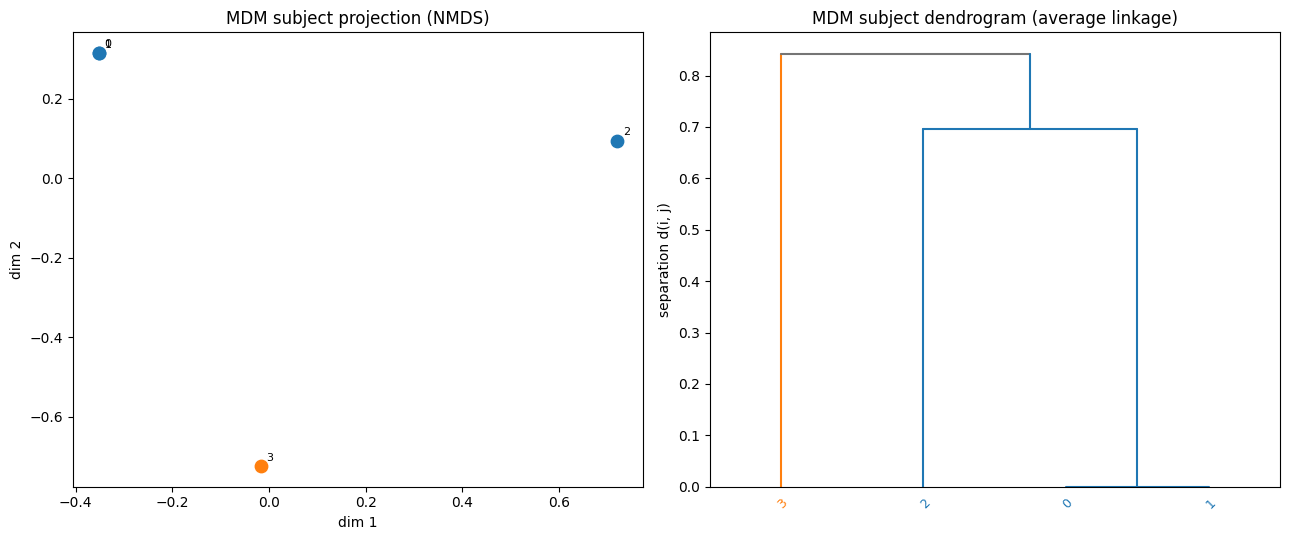

In [19]:
inds = individuals
fig = plot_mdp(dist, technique="nmds")

In [20]:
import mdmp
help(mdmp.MDM)

Help on class MDM in module mdmp.model.model:

class MDM(builtins.object)
 |  MDM(data: Union[numpy.ndarray, pandas.core.frame.DataFrame], method: Literal['hc', 'tabu', 'mmhc'] = 'hc', nbf: int = 15, delta: Optional[numpy.ndarray] = None, verbose: bool = True, n_jobs: Optional[int] = None, **kwargs)
 |
 |  Multiregression Dynamic Model (MDM) for Bayesian network structure learning
 |  and dynamic parameter estimation from multivariate time series data.
 |
 |  Attributes
 |  ----------
 |  adj_mat : np.ndarray
 |      Adjacency matrix representing the learned DAG structure.
 |  data : np.ndarray
 |      Original input data (T x N).
 |  DF : dict
 |      Discount factor estimation results.
 |  Filt : dict
 |      Filtered dynamic parameters.
 |  Smoo : dict
 |      Smoothed dynamic parameters.
 |  node_names : list of str
 |      Names of the nodes/variables.
 |
 |  Methods defined here:
 |
 |  __init__(self, data: Union[numpy.ndarray, pandas.core.frame.DataFrame], method: Literal['hc', 